In [1]:
import json
import os
import ctypes

import numpy as np
import pandas as pd

from PIL import Image
import matplotlib.pyplot as plt

from pycocotools.coco import COCO
os.environ["SM_FRAMEWORK"]="tf.keras"
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.utils import Sequence, load_img
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten

from keras_preprocessing.image import img_to_array

import segmentation_models as sm

Segmentation Models: using `tf.keras` framework.


In [2]:
ctypes.windll.kernel32.SetThreadExecutionState(0x80000002)


-2147483648

In [3]:
test_img="./arcade/stenosis/test/images/"
train_img="./arcade/stenosis/train/images/"
val_img="./arcade/stenosis/val/images/"

In [4]:
js_train="./arcade/stenosis/train/annotations/train.json"
js_val="./arcade/stenosis/val/annotations/val.json"
js_test="./arcade/stenosis/test/annotations/test.json"

with open (js_train,"r") as f:
    js_tra=json.load(f)

with open (js_val,"r") as b:
    js_v=json.load(b)

with open (js_test,"r") as c:
    js_te=json.load(c)

In [5]:
def load_imggg(join_path,img_dir):
    coco=COCO(join_path,)
    img_di=coco.getImgIds()
    img=[]
    for i in img_di:
        img_l=coco.loadImgs(i)[0]
        img_path=os.path.join(img_dir,img_l["file_name"])
        imgg=load_img(img_path,target_size=(512,512),color_mode="grayscale")
        imgg=img_to_array(imgg)
        img.append(imgg)
    return np.array(img)

x_train=load_imggg(js_train,train_img)
x_test=load_imggg(js_test,test_img)
x_val=load_imggg(js_val,val_img)

print("x_train shape:",x_train.shape)
print("x_test shape:",x_test.shape)
print("x_val shape:",x_val.shape)

loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
x_train shape: (1000, 512, 512, 1)
x_test shape: (300, 512, 512, 1)
x_val shape: (200, 512, 512, 1)


In [6]:
print("train:",x_train.shape)
print("test:",x_test.shape)
print("val:",x_val.shape)

train: (1000, 512, 512, 1)
test: (300, 512, 512, 1)
val: (200, 512, 512, 1)


In [7]:
def make_masks(json_path):
    coco=COCO(json_path)
    img_ids=coco.getImgIds()
    masks=[]

    for img_id in img_ids:

        img_info=coco.loadImgs(img_id)[0]
        anns=coco.loadAnns(coco.getAnnIds(imgIds=img_id))
        mask=np.zeros(
            (img_info["height"],img_info["width"]),
            dtype=np.uint8)
        for ann in anns:
            mask=np.maximum(mask,coco.annToMask(ann))

        mask=Image.fromarray(mask)
        mask=mask.resize(
            (512,512),
            Image.NEAREST)
        masks.append(np.array(mask))
    masks=np.array(masks)
    masks=np.expand_dims(masks,-1)

    return masks

In [8]:
y_train=make_masks(js_train)
y_val=make_masks(js_val)
y_test=make_masks(js_test)

loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


In [9]:
print("val mask:",y_val.shape)
print("test mask:",y_test.shape)
print("train mask:",y_train.shape)

val mask: (200, 512, 512, 1)
test mask: (300, 512, 512, 1)
train mask: (1000, 512, 512, 1)


In [10]:
print(x_train.shape)
print(y_train.shape)

(1000, 512, 512, 1)
(1000, 512, 512, 1)


In [11]:
print(js_tra["images"][0])
print("image:",x_train[0].shape)
print("mask:",y_train[0].shape)

{'id': 676, 'width': 512, 'height': 512, 'file_name': '676.png', 'license': 0, 'flickr_url': '', 'coco_url': '', 'date_captured': 0}
image: (512, 512, 1)
mask: (512, 512, 1)


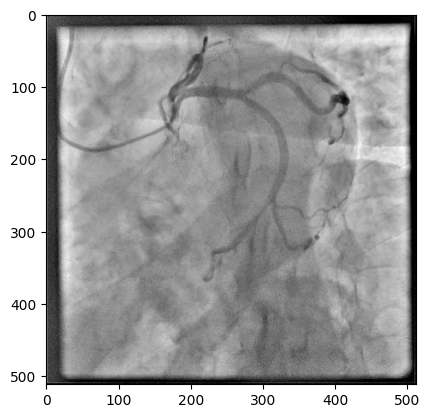

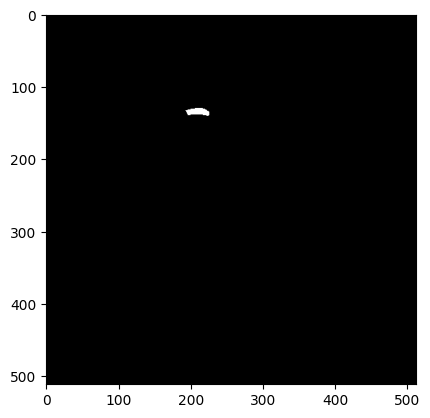

In [12]:
plt.imshow(x_train[0].squeeze(),cmap="gray")
plt.show()

plt.imshow(y_train[0].squeeze(),cmap="gray")
plt.show()

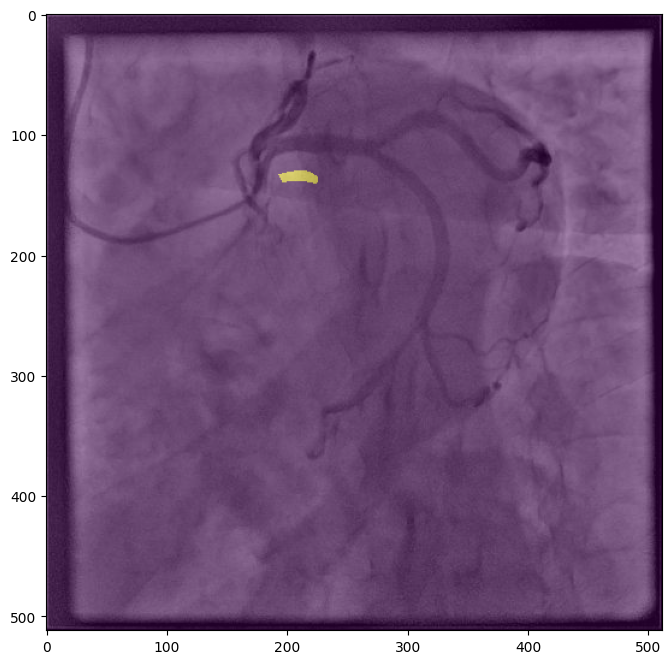

In [13]:
plt.figure(figsize=(8,8))

plt.imshow(x_train[0].squeeze(), cmap="gray")
plt.imshow(y_train[0].squeeze(), alpha=0.5)

plt.show()

In [14]:
x_train=x_train/255.0
x_val=x_val/255.0
x_test=x_test/255.0

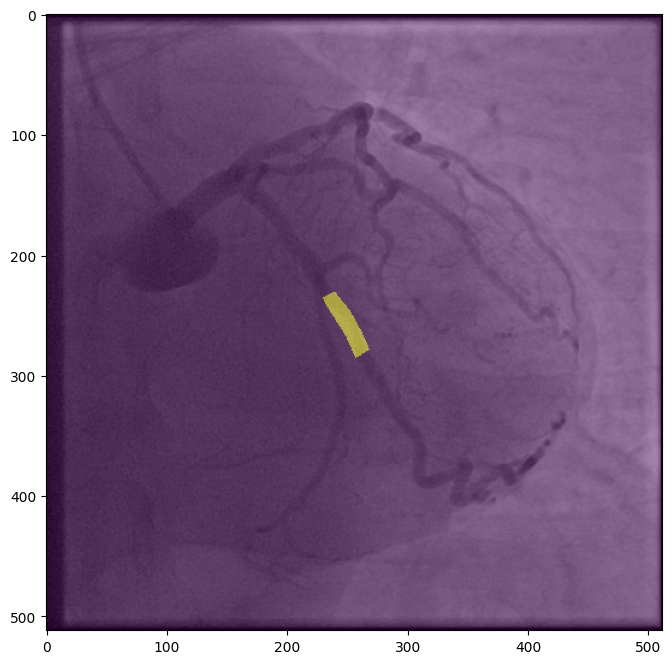

In [15]:
i=0

plt.figure(figsize=(8,8))

plt.imshow(x_test[i].squeeze(),cmap="gray")
plt.imshow(y_test[i].squeeze(),alpha=0.5)

plt.show()

In [16]:
model=sm.Unet('resnet34',input_shape=(512,512,1),activation="sigmoid",encoder_weights=None,classes=1)

In [17]:
model.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])


In [18]:
gpu=tf.config.list_physical_devices("GPU")
print(gpu)

[]


In [19]:
y_train=y_train.astype("float32")
y_val=y_val.astype("float32")
y_test=y_test.astype("float32")

In [20]:
history=model.fit(x_train,y_train,validation_data=(x_val,y_val),epochs=100,batch_size=2)

Epoch 1/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 1106s 2s/step - accuracy: 0.9917 - loss: 0.0499 - val_accuracy: 0.9919 - val_loss: 0.1291
Epoch 2/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 488s 976ms/step - accuracy: 0.9927 - loss: 0.0335 - val_accuracy: 0.9920 - val_loss: 0.0390
Epoch 3/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 501s 1s/step - accuracy: 0.9927 - loss: 0.0319 - val_accuracy: 0.9920 - val_loss: 0.0411
Epoch 4/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 504s 1s/step - accuracy: 0.9927 - loss: 0.0314 - val_accuracy: 0.9920 - val_loss: 0.0284
Epoch 5/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 511s 1s/step - accuracy: 0.9927 - loss: 0.0308 - val_accuracy: 0.9920 - val_loss: 0.0424
Epoch 6/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 513s 1s/step - accuracy: 0.9927 - loss: 0.0305 - val_accuracy: 0.9920 - val_loss: 0.0281
Epoch 7/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 509s 1s/step - accuracy: 0.9927 - loss: 0.0302 - val_accuracy: 0.9920 - val_loss: 0.0284
Epoch 8/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 512s 1s/step - accuracy: 0.9927 - loss: 0.030

In [21]:
model.save("heart.keras")

In [63]:
print(f" count train:{len(os.listdir(train_img))}")
print(f" count val:{len(os.listdir(val_img))}")
print(f" count test:{len(os.listdir(test_img))}")

 count train:1000
 count val:200
 count test:300


In [64]:
print(len(history.history["loss"]))
print(history.history["loss"])

100
[0.049861978739500046, 0.03349405154585838, 0.03187254071235657, 0.031392134726047516, 0.030839890241622925, 0.03051663562655449, 0.030210640281438828, 0.030034681782126427, 0.02983589842915535, 0.02937963977456093, 0.02960178628563881, 0.028889385983347893, 0.02882242575287819, 0.02869979850947857, 0.02810129150748253, 0.027859369292855263, 0.02752920798957348, 0.027299413457512856, 0.026723280549049377, 0.026423078030347824, 0.025842642411589622, 0.025718357414007187, 0.02555433288216591, 0.024932775646448135, 0.024391522631049156, 0.024359451606869698, 0.023728379979729652, 0.023443320766091347, 0.022949540987610817, 0.02255539409816265, 0.02191934362053871, 0.021862342953681946, 0.021254468709230423, 0.020662009716033936, 0.0200053621083498, 0.019535433501005173, 0.01911122351884842, 0.01793580688536167, 0.017049722373485565, 0.016394199803471565, 0.015526175498962402, 0.014388155192136765, 0.013512209989130497, 0.012709826231002808, 0.011717963963747025, 0.011163333430886269, 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step


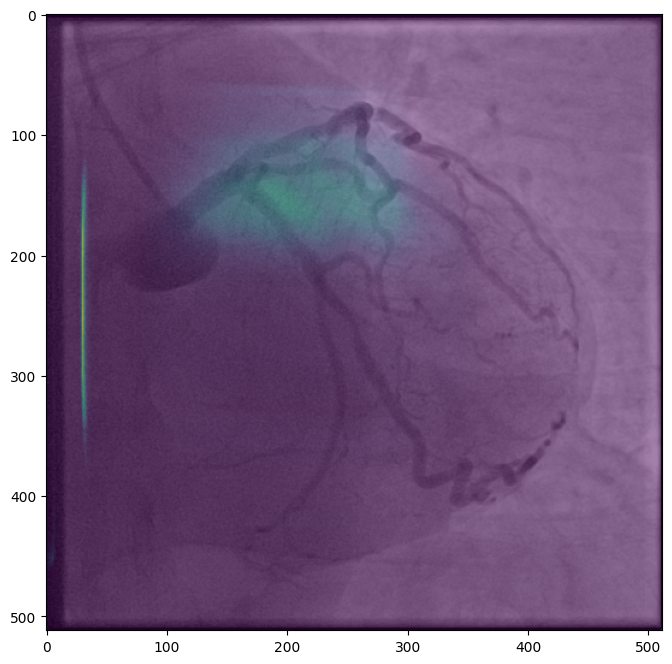

In [65]:
i=0
pred=model.predict(x_test[i:i+1])
plt.figure(figsize=(8,8))

plt.imshow(x_test[i].squeeze(),cmap="gray")
plt.imshow(pred[0].squeeze(),alpha=0.5)

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step


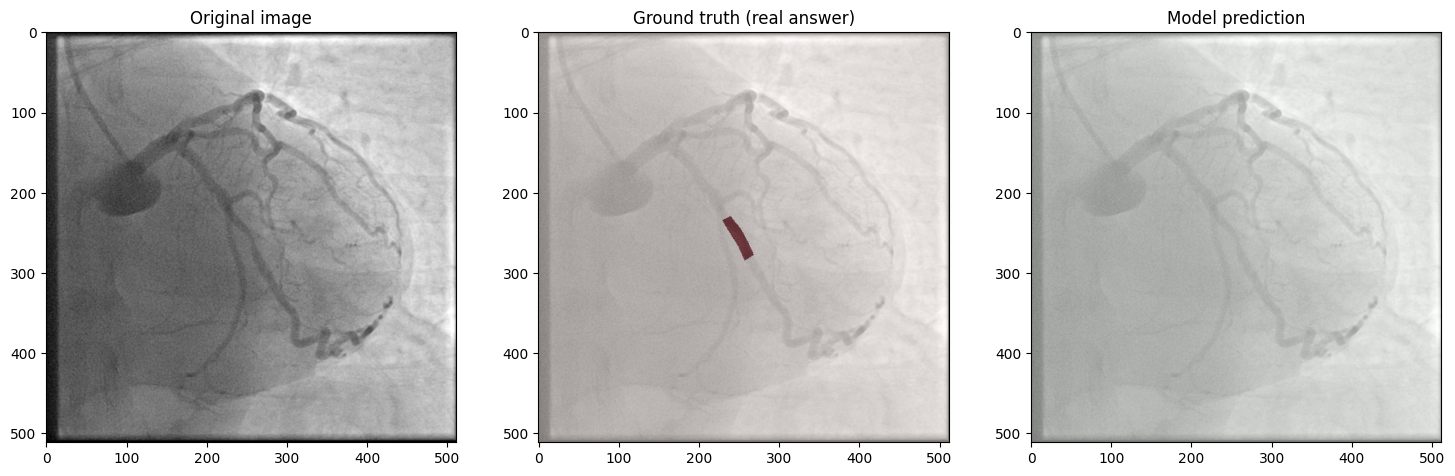

IoU 1.3020833e-08
Dice 1.3020833e-08


In [66]:
i = 0

pred=model.predict(x_test[i:i+1])
pred_mask=(pred[0]>0.05).astype("uint8")

fig,axes=plt.subplots(1,3,figsize=(18, 6))

axes[0].imshow(x_test[i].squeeze(),cmap="gray")
axes[0].set_title("Original image")
axes[1].imshow(x_test[i].squeeze(),cmap="gray")
axes[1].imshow(y_test[i].squeeze(),alpha=0.5,cmap="Reds")
axes[1].set_title("Ground truth (real answer)")
axes[2].imshow(x_test[i].squeeze(),cmap="gray")
axes[2].imshow(pred_mask.squeeze(),alpha=0.5,cmap="Greens")
axes[2].set_title("Model prediction")

plt.show()

from segmentation_models.metrics import IOUScore, FScore
y_single=y_test[i:i+1].astype("float32")
pred_single=pred.astype("float32")
iou=IOUScore(threshold=0.05)
dice=FScore(beta=1, threshold=0.05)

print("IoU",iou(y_single,pred_single).numpy())
print("Dice",dice(y_single,pred_single).numpy())

In [67]:
new_im="F://54.png"
img_loder_test=load_img(new_im,target_size=(512,512),color_mode="grayscale")

img=img_to_array(img_loder_test)
img=img/255.0
img=np.expand_dims(img,axis=0)
پpred=model.predict(img)
pred_mask=pred[0]
pred_msk=(pred_mask>0.5).astype("uint8")
print(pred_msk.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step
(512, 512, 1)


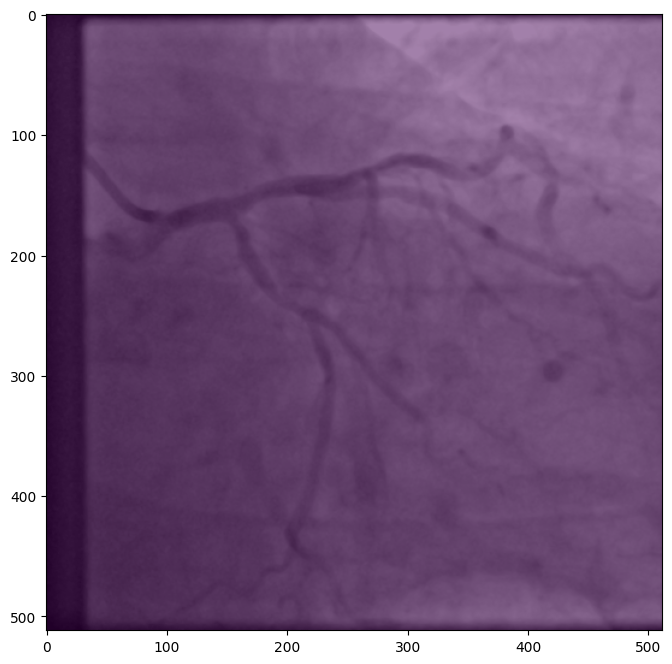

In [68]:
plt.figure(figsize=(8,8))
plt.imshow(img[0].squeeze(), cmap="gray")
plt.imshow(pred_msk.squeeze(),alpha=0.5)
plt.show()

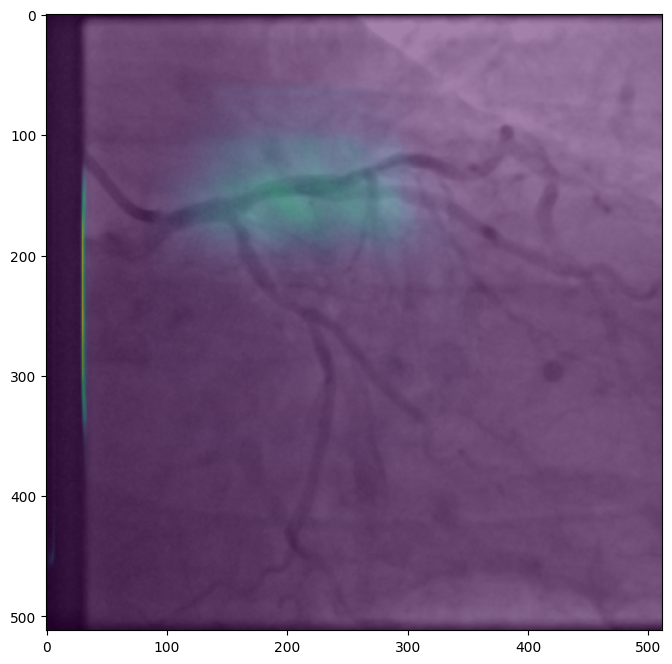

In [69]:
pred_msk=(pred_mask>0.1).astype("uint8")

plt.figure(figsize=(8,8))
plt.imshow(img[0].squeeze(),cmap="gray")
plt.imshow(pred_mask.squeeze(),alpha=0.5)
plt.show()

In [70]:
print(pred.min(), pred.max(), pred.mean())

4.73883e-14 6.522659e-05 1.8962608e-06


In [71]:
new_im2="F://165.png"
img_loder_test2=load_img(new_im2,target_size=(512,512),color_mode="grayscale")

img2=img_to_array(img_loder_test2)
img2=img2/255.0
img2=np.expand_dims(img2,axis=0)
pred2=model.predict(img2)
pred_mask2=pred2[0]
pred_msk2=(pred_mask2>0.5).astype("uint8")
print(pred_msk2.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step
(512, 512, 1)


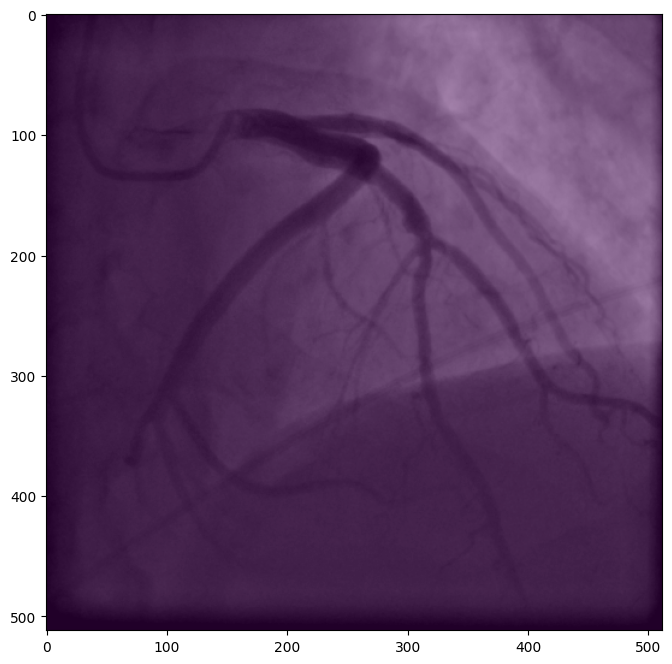

In [72]:
test_again=(pred_mask2>0.1).astype("uint8")

plt.figure(figsize=(8,8))

plt.imshow(img2[0].squeeze(),cmap="gray")
plt.imshow(test_again.squeeze(),alpha=0.5)

plt.show()

In [73]:
print(pred.max())
print(pred.min())
print(np.sum(pred_msk))

6.522659e-05
4.73883e-14
0


In [74]:
print("min:", pred_test.min())
print("max:", pred_test.max())
print("mean:", pred_test.mean())

min: 4.232243e-14
max: 0.00019754781
mean: 1.8552989e-06


In [75]:
from segmentation_models.metrics import IOUScore,FScore
pred_test=model.predict(x_test)

y_test=y_test.astype("float32")

pred_mask2=pred_mask2.astype("float32")

iou=IOUScore(threshold=0.5)
dice=FScore(beta=1,threshold=0.5)

print("IOU:",iou(y_test,pred_test).numpy())
print("Dice:",dice(y_test,pred_test).numpy())

10/10 ━━━━━━━━━━━━━━━━━━━━ 30s 3s/step
IOU: 1.3883528e-11
Dice: 1.3883528e-11


In [62]:
for t in [0.01, 0.02, 0.03, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5]:
    iou = IOUScore(threshold=t)
    dice = FScore(beta=1, threshold=t)
    print(t, iou(y_test, pred_test).numpy(), dice(y_test, pred_test).numpy())

0.01 1.3883528e-11 1.3883528e-11
0.02 1.3883528e-11 1.3883528e-11
0.03 1.3883528e-11 1.3883528e-11
0.05 1.3883528e-11 1.3883528e-11
0.1 1.3883528e-11 1.3883528e-11
0.2 1.3883528e-11 1.3883528e-11
0.3 1.3883528e-11 1.3883528e-11
0.4 1.3883528e-11 1.3883528e-11
0.5 1.3883528e-11 1.3883528e-11


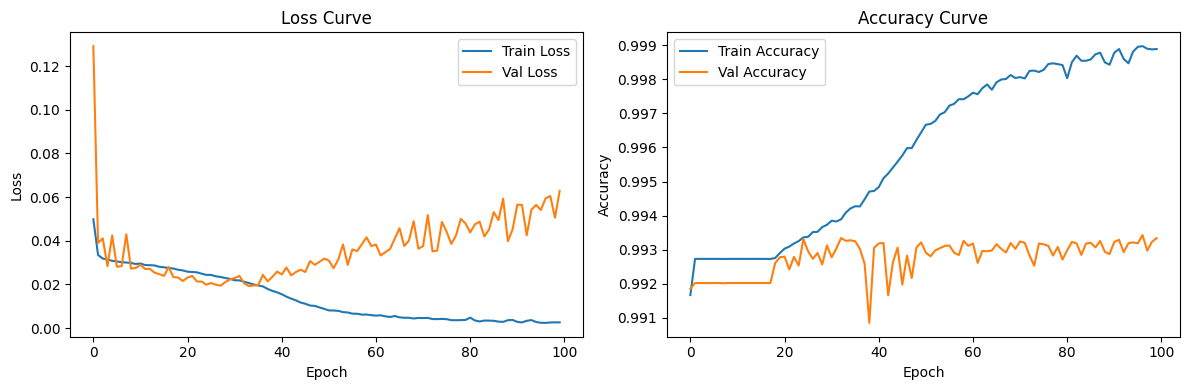

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'],label='Train Loss')
plt.plot(history.history['val_loss'],label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Curve')

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'],label='Train Accuracy')
plt.plot(history.history['val_accuracy'],label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy Curve')

plt.tight_layout()
plt.show()

In [39]:
def load_images_coco(json_path, img_dir):
    coco=COCO(json_path)
    img_ids=coco.getImgIds()
    images=[]
    for img_id in img_ids:
        img_p=coco.loadImgs(img_id)[0]
        img_path=os.path.join(img_dir, img_p["file_name"])
        img=load_img(img_path, target_size=(512,512), color_mode="grayscale")
        img=img_to_array(img)
        images.append(img)
    return np.array(images)

x_train=load_images_coco(js_train,train_img)
val_a=load_images_coco(js_val,val_img)
x_test =load_images_coco(js_test,test_img)

loading annotations into memory...
Done (t=0.03s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!


In [77]:
print("x_test min/max:", x_test.min(), x_test.max())

pred_test = model.predict(x_test)
print("pred_test min/max/mean:", pred_test.min(), pred_test.max(), pred_test.mean())

y_test = y_test.astype("float32")
pred_test = pred_test.astype("float32")

for t in [0.01, 0.05, 0.1, 0.3, 0.5]:
    iou = IOUScore(threshold=t)
    dice = FScore(beta=1, threshold=t)
    print(t, iou(y_test, pred_test).numpy(), dice(y_test, pred_test).numpy())

x_test min/max: 0.0 0.003921569
10/10 ━━━━━━━━━━━━━━━━━━━━ 31s 3s/step
pred_test min/max/mean: 4.232243e-14 0.00019754781 1.8552989e-06
0.01 1.3883528e-11 1.3883528e-11
0.05 1.3883528e-11 1.3883528e-11
0.1 1.3883528e-11 1.3883528e-11
0.3 1.3883528e-11 1.3883528e-11
0.5 1.3883528e-11 1.3883528e-11


In [78]:
# بازسازی کامل و تمیز x_test (بدون اعتماد به حافظه‌ی قبلی)
x_test_fresh = load_imggg(js_test, test_img)
x_test_fresh = x_test_fresh / 255.0

print("x_test_fresh min/max:", x_test_fresh.min(), x_test_fresh.max())

pred_test = model.predict(x_test_fresh)
print("pred_test min/max/mean:", pred_test.min(), pred_test.max(), pred_test.mean())

y_test = y_test.astype("float32")
pred_test = pred_test.astype("float32")

for t in [0.01, 0.05, 0.1, 0.3, 0.5]:
    iou = IOUScore(threshold=t)
    dice = FScore(beta=1, threshold=t)
    print(t, iou(y_test, pred_test).numpy(), dice(y_test, pred_test).numpy())

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
x_test_fresh min/max: 0.0 1.0
10/10 ━━━━━━━━━━━━━━━━━━━━ 32s 3s/step
pred_test min/max/mean: 4.6793962e-26 1.0 0.003082439
0.01 0.27199644 0.42766854
0.05 0.25541082 0.406896
0.1 0.24466598 0.39314318
0.3 0.2193229 0.3597454
0.5 0.19992721 0.33323225


In [45]:
model=tf.keras.models.load_model("heart.keras", compile=False)
x_test = x_test / 255.0

pred_test=model.predict(x_test)

y_test=y_test.astype("float32")
pred_test=pred_test.astype("float32")
for t in [0.05, 0.1, 0.2, 0.3, 0.4, 0.5]:
    iou=IOUScore(threshold=t)
    dice=FScore(beta=1, threshold=t)
    print(t,iou(y_test, pred_test).numpy(),dice(y_test,pred_test).numpy())

10/10 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step
0.05 1.1126552e-11 1.1126552e-11
0.1 1.113551e-11 1.113551e-11
0.2 1.1145178e-11 1.1145178e-11
0.3 1.1152188e-11 1.1152188e-11
0.4 1.1158161e-11 1.1158161e-11
0.5 1.11635545e-11 1.11635545e-11


In [46]:
x_test = x_test / 255.0           # 👈 این باید اول بیاد

model=tf.keras.models.load_model("heart.keras", compile=False)
pred_test=model.predict(x_test)   # 👈 حالا با داده‌ی نرمالایز شده پیش‌بینی می‌شه

y_test=y_test.astype("float32")
pred_test=pred_test.astype("float32")

for t in [0.05, 0.1, 0.2, 0.3, 0.4, 0.5]:
    iou=IOUScore(threshold=t)
    dice=FScore(beta=1, threshold=t)
    print(t,iou(y_test, pred_test).numpy(),dice(y_test,pred_test).numpy())

10/10 ━━━━━━━━━━━━━━━━━━━━ 31s 3s/step
0.05 1.3883528e-11 1.3883528e-11
0.1 1.3883528e-11 1.3883528e-11
0.2 1.3883528e-11 1.3883528e-11
0.3 1.3883528e-11 1.3883528e-11
0.4 1.3883528e-11 1.3883528e-11
0.5 1.3883528e-11 1.3883528e-11


In [41]:
for t in [0.05,0.1,0.2,0.3,0.4,0.5]:

    iou=IOUScore(threshold=t)
    dice=FScore(beta=1,threshold=t)

    print(t,
          iou(y_test,pred_test).numpy(),
          dice(y_test,pred_test).numpy())

0.05 1.1126552e-11 1.1126552e-11
0.1 1.113551e-11 1.113551e-11
0.2 1.1145178e-11 1.1145178e-11
0.3 1.1152188e-11 1.1152188e-11
0.4 1.1158161e-11 1.1158161e-11
0.5 1.11635545e-11 1.11635545e-11


In [42]:
best_dice=0
best_t=0

for t in np.arange(0.01,0.5,0.01):

    dice=FScore(beta=1,threshold=t)

    d=dice(y_test,pred_test).numpy()

    if d>best_dice:
        best_dice=d
        best_t=t

print("best threshold:",best_t)
print("best dice:",best_dice)

best threshold: 0.49
best dice: 1.1162994e-11


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step


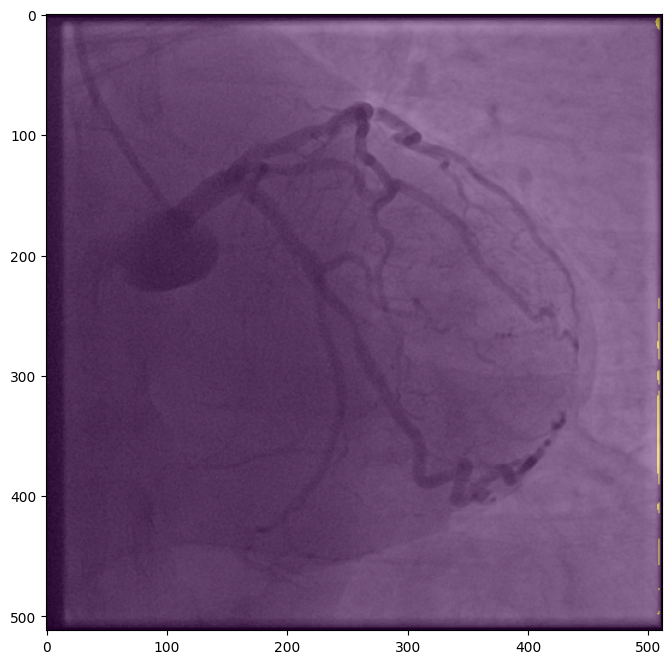

In [43]:
pred_mask=model.predict(x_test[0:1])

mask=(pred_mask[0]>0.06).astype("uint8")

plt.figure(figsize=(8,8))
plt.imshow(x_test[0].squeeze(),cmap="gray")
plt.imshow(mask.squeeze(),alpha=0.5)

plt.show()

In [ ]:
os.system("shutdown /s /t 60")

In [ ]:
print(js_tra.keys())

print(js_tra["annotations"][0])

In [ ]:
print(y_train[0].max())
print(np.sum(y_train[0]))

In [ ]:
print(tf.config.list_physical_devices("GPU"))

In [ ]:
import tensorflow as tf
print("TF version:", tf.__version__)
print("Built with CUDA:", tf.test.is_built_with_cuda())

In [44]:
model=tf.keras.models.load_model("heart.keras", compile=False)
pred_test=model.predict(x_test)

y_test=y_test.astype("float32")
pred_test=pred_test.astype("float32")

for t in [0.05, 0.1, 0.2, 0.3, 0.4, 0.5]:
    iou=IOUScore(threshold=t)
    dice=FScore(beta=1, threshold=t)
    print(t,iou(y_test, pred_test).numpy(),dice(y_test,pred_test).numpy())

10/10 ━━━━━━━━━━━━━━━━━━━━ 32s 3s/step
0.05 1.1126552e-11 1.1126552e-11
0.1 1.113551e-11 1.113551e-11
0.2 1.1145178e-11 1.1145178e-11
0.3 1.1152188e-11 1.1152188e-11
0.4 1.1158161e-11 1.1158161e-11
0.5 1.11635545e-11 1.11635545e-11
